In [ ]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-4njzxh6w
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-4njzxh6w
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 443a79479c90be4cc23adf7fe08db6e2a283e224
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=11018 sha256=625e976658c98fd354f8800768c3a78a3d8cbb470e09e9c1d34f9ba15defe80f
  Stored in directory: /tmp/pip-ephem-wheel-cache-hj7b45xf/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp4zmxtklc".


In [ ]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [ ]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")

File does not exist!


In [ ]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gill.jpg to gill.jpg


In [ ]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('gill.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")

File exists!


In [ ]:
pwd

'/content'

In [ ]:
ls /content/gill.jpg

/content/gill.jpg


In [ ]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('/content/gill.jpg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")

Image read successfully.


In [ ]:
%%writefile sobelEdgeDetectionFilter.cu
#include <iostream>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>
#include <cmath>

using namespace cv;

// CUDA Kernel for Sobel Edge Detection
__global__ void sobelFilter(unsigned char *srcImage, unsigned char *dstImage, unsigned int width, unsigned int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    // Boundary check for thread layout
    if (x >= width || y >= height) return;

    // Set boundary pixels to black (0) to avoid out-of-bounds array access
    if (x == 0 || x == width - 1 || y == 0 || y == height - 1) {
        dstImage[y * width + x] = 0;
        return;
    }

    // Horizontal gradient operator (Gx)
    // [-1  0  1]
    // [-2  0  2]
    // [-1  0  1]
    int Gx = -1 * srcImage[(y - 1) * width + (x - 1)] + 1 * srcImage[(y - 1) * width + (x + 1)]
             - 2 * srcImage[y       * width + (x - 1)] + 2 * srcImage[y       * width + (x + 1)]
             - 1 * srcImage[(y + 1) * width + (x - 1)] + 1 * srcImage[(y + 1) * width + (x + 1)];

    // Vertical gradient operator (Gy)
    // [-1 -2 -1]
    // [ 0  0  0]
    // [ 1  2  1]
    int Gy = -1 * srcImage[(y - 1) * width + (x - 1)] - 2 * srcImage[(y - 1) * width + x] - 1 * srcImage[(y - 1) * width + (x + 1)]
             + 1 * srcImage[(y + 1) * width + (x - 1)] + 2 * srcImage[(y + 1) * width + x] + 1 * srcImage[(y + 1) * width + (x + 1)];

    // Compute edge magnitude: sqrt(Gx^2 + Gy^2)
    int magnitude = sqrtf((float)(Gx * Gx + Gy * Gy));

    // Clamp value to [0, 255] range
    if (magnitude > 255) magnitude = 255;

    dstImage[y * width + x] = (unsigned char)magnitude;
}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {
    // Read input image as grayscale
    Mat image = imread("/content/gill.jpg", IMREAD_GRAYSCALE);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;
    size_t imageSize = width * height * sizeof(unsigned char);

    // Allocate host memory for output image
    unsigned char *h_outputImage = (unsigned char *)malloc(imageSize);
    if (h_outputImage == nullptr) {
        fprintf(stderr, "Failed to allocate host memory\n");
        return -1;
    }

    // Allocate device memory
    unsigned char *d_inputImage, *d_outputImage;
    checkCudaErrors(cudaMalloc(&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, imageSize));
    checkCudaErrors(cudaMemcpy(d_inputImage, image.data, imageSize, cudaMemcpyHostToDevice));

    // Define CUDA events for timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Launch kernel
    dim3 blockSize(16, 16);
    dim3 gridSize((width + blockSize.x - 1) / blockSize.x, (height + blockSize.y - 1) / blockSize.y);

    cudaEventRecord(start);
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage, d_outputImage, width, height);
    cudaEventRecord(stop);

    // Synchronize events
    cudaEventSynchronize(stop);

    // Calculate elapsed time
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    checkCudaErrors(cudaMemcpy(h_outputImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost));

    // Write output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);
    imwrite("output_sobel.jpeg", outputImage);

    // Free memory
    free(h_outputImage);
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    // Destroy CUDA events
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    // Print elapsed time
    printf("Total time taken: %f milliseconds\n", milliseconds);

    return 0;
}

Writing sobelEdgeDetectionFilter.cu


In [ ]:
!apt-get update && apt-get install -y libopencv-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [105 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,899 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,158 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-sec

In [ ]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [ ]:
!./sobelEdgeDetectionFilter


Total time taken: 137.307175 milliseconds


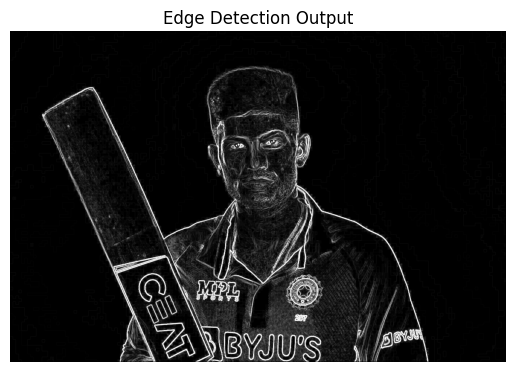

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = '/content/output_sobel.jpeg'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

# Display the image
plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')  # Hide the axes
plt.show()